<a href="https://colab.research.google.com/github/HebaRouk/-Build-a-ML-Workflow-For-Scones-Unlimited-On-Amazon-SageMaker/blob/main/CV701_lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV701 Lab 3: Image Filtering


## Demo

In [18]:
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

In [19]:
img = io.imread("cameraman.tif")

In [20]:
img.shape

(256, 256)

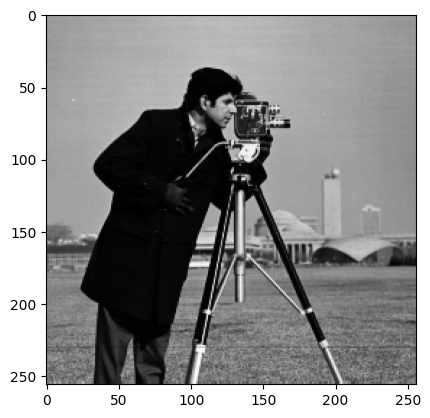

In [21]:
plt.imshow(img, cmap='gray')

# Add Gaussian Noise to the image

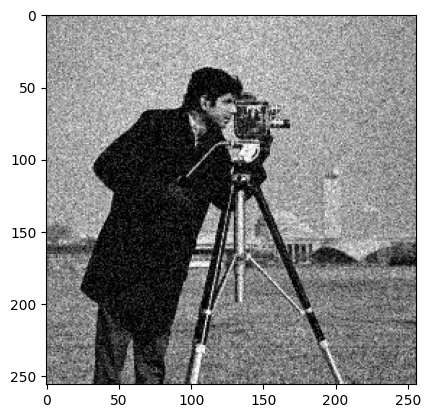

In [22]:
def add_noise(img, mu=0, sigma=0.1):
    """
    Adds Gaussian noise to the image.
    sigma is given relative to the [0, 255] range (0.1 -> 25.5 grey levels).
    The result is clipped to [0, 255] so the image itself is not rescaled.
    """
    rand_noise = np.random.normal(mu, sigma, img.shape) * 255
    noisy_img = np.clip(img + rand_noise, 0, 255)
    return noisy_img

np.random.seed(0)
noisy_img = add_noise(img)
plt.imshow(noisy_img, cmap='gray', vmin=0, vmax=255)

# Compute MSE between original image and the noisy version

In [23]:
np.square(img.astype(float) - noisy_img.astype(float)).mean()

np.float64(585.3129964056373)

In [24]:
np.square(img.astype(float) - img.astype(float)).mean()

np.float64(0.0)

# Implement Gaussian filtering (blur)

In [25]:
def gaussian_blur(img, kernel_size, sigma):
    ax = np.arange(kernel_size) - kernel_size // 2
    x, y = np.meshgrid(ax, ax)
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()

    pad = kernel_size // 2
    padded_image = np.pad(img, pad, mode='reflect')

    blurred_image = np.zeros(img.shape)
    for h in range(img.shape[0]):
        for w in range(img.shape[1]):
            blurred_image[h, w] = np.sum(padded_image[h:h+kernel_size, w:w+kernel_size] * kernel)

    return blurred_image

MSE noisy:   585.3129964056373
MSE blurred: 213.67642505498256


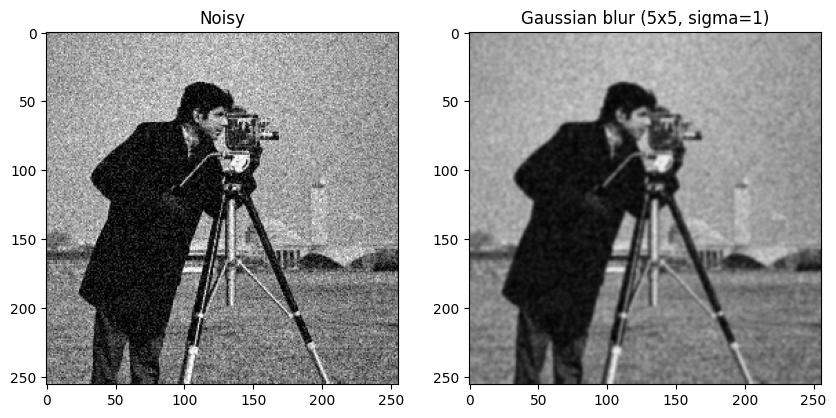

In [26]:
blurred = gaussian_blur(noisy_img, 5, 1)

print("MSE noisy:  ", np.square(img.astype(float) - noisy_img).mean())
print("MSE blurred:", np.square(img.astype(float) - blurred).mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(noisy_img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Noisy")
axes[1].imshow(blurred, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Gaussian blur (5x5, sigma=1)")
plt.show()

# Lab Activities

## Helper functions
Implement MSE and PSNR functions according to their formulas

$$\mathrm{MSE}(I, K) = \frac{1}{HW}\sum_{i,j}\big(I(i,j) - K(i,j)\big)^2 \qquad
\mathrm{PSNR}(I, K) = 10\log_{10}\frac{255^2}{\mathrm{MSE}(I, K)}$$

In [27]:
def mse(img_a, img_b):
    img_a = img_a.astype(float)
    img_b = img_b.astype(float)
    return np.mean((img_a - img_b) ** 2)


def psnr(img_a, img_b):
    error = mse(img_a, img_b)
    if error == 0:
        return float('inf')
    return 10 * np.log10((255 ** 2) / error)

## 1. Salt and pepper noise
Implement salt and pepper noise and add it to the image above

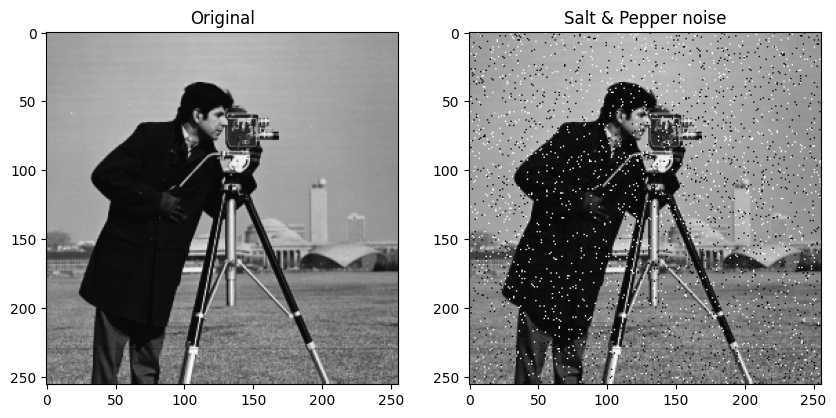

In [28]:
def add_salt_and_pepper(img, amount=0.05):
    """
    Adds salt-and-pepper noise to the image.
    amount is the fraction of pixels that get corrupted; half become
    "salt" (255) and half become "pepper" (0).
    """
    noisy_img = img.copy().astype(float)
    num_pixels = img.size

    # Salt: set a random half of the corrupted pixels to 255
    num_salt = int(np.ceil(amount * num_pixels * 0.5))
    coords = [np.random.randint(0, dim, num_salt) for dim in img.shape]
    noisy_img[tuple(coords)] = 255

    # Pepper: set the other half to 0
    num_pepper = int(np.ceil(amount * num_pixels * 0.5))
    coords = [np.random.randint(0, dim, num_pepper) for dim in img.shape]
    noisy_img[tuple(coords)] = 0

    return noisy_img


np.random.seed(0)
sp_img = add_salt_and_pepper(img)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
axes[1].imshow(sp_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Salt & Pepper noise")
plt.show()

## 2. Mean and Median filters
Implement functions to carry out Mean and Median filters.

In [29]:
def mean_filter(img, kernel_size=3):
    pad = kernel_size // 2
    padded_image = np.pad(img, pad, mode='reflect')

    filtered_image = np.zeros(img.shape)
    for h in range(img.shape[0]):
        for w in range(img.shape[1]):
            window = padded_image[h:h + kernel_size, w:w + kernel_size]
            filtered_image[h, w] = np.mean(window)

    return filtered_image


def median_filter(img, kernel_size=3):
    pad = kernel_size // 2
    padded_image = np.pad(img, pad, mode='reflect')

    filtered_image = np.zeros(img.shape)
    for h in range(img.shape[0]):
        for w in range(img.shape[1]):
            window = padded_image[h:h + kernel_size, w:w + kernel_size]
            filtered_image[h, w] = np.median(window)

    return filtered_image

## 3. Compare the Gaussian, Mean and Median filters
Using MSE as a metric, compare the impact of the Gaussian, Mean, and Median filters on denoising **both** the
Gaussian-noise image and the salt-and-pepper-noise image. Then analyse your results.

Gaussian noise image, MSE before filtering: 585.3129964056373
  Gaussian filter  MSE = 213.676
  Mean filter      MSE = 236.860
  Median filter    MSE = 238.090

Salt & pepper noise image, MSE before filtering: 996.3146362304688
  Gaussian filter  MSE = 256.663
  Mean filter      MSE = 289.222
  Median filter    MSE = 132.322


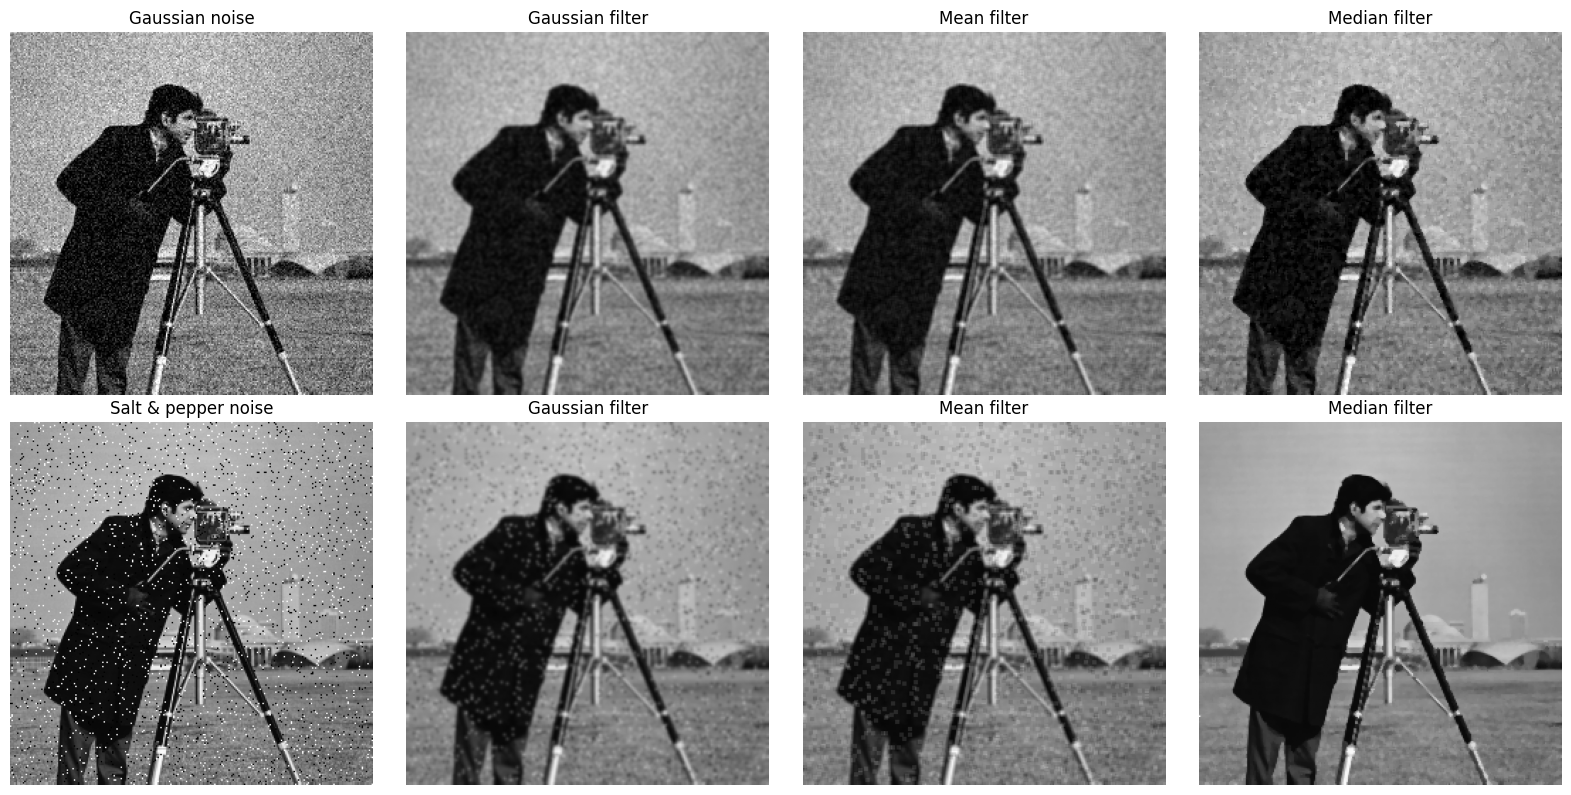

In [30]:
np.random.seed(0)

# Two noisy versions of the original image
gauss_img = add_noise(img)
sp_img = add_salt_and_pepper(img)

# Apply each filter to both noisy images
gauss_denoised = {
    "Gaussian filter": gaussian_blur(gauss_img, 5, 1),
    "Mean filter":     mean_filter(gauss_img, 3),
    "Median filter":   median_filter(gauss_img, 3),
}

sp_denoised = {
    "Gaussian filter": gaussian_blur(sp_img, 5, 1),
    "Mean filter":     mean_filter(sp_img, 3),
    "Median filter":   median_filter(sp_img, 3),
}

print("Gaussian noise image, MSE before filtering:", mse(img, gauss_img))
for name, result in gauss_denoised.items():
    print(f"  {name:16s} MSE = {mse(img, result):.3f}")

print()
print("Salt & pepper noise image, MSE before filtering:", mse(img, sp_img))
for name, result in sp_denoised.items():
    print(f"  {name:16s} MSE = {mse(img, result):.3f}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes[0, 0].imshow(gauss_img, cmap='gray', vmin=0, vmax=255); axes[0, 0].set_title("Gaussian noise")
for ax, (name, result) in zip(axes[0, 1:], gauss_denoised.items()):
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name)

axes[1, 0].imshow(sp_img, cmap='gray', vmin=0, vmax=255); axes[1, 0].set_title("Salt & pepper noise")
for ax, (name, result) in zip(axes[1, 1:], sp_denoised.items()):
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(name)

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

**Your analysis:**
The median filter gives by far the lowest MSE on the salt-and-pepper image, because it replaces each pixel with the middle value of its neighbourhood, so the extreme 0/255 outlier values are simply discarded instead of being averaged in.
The mean and Gaussian filters reduce the salt-and-pepper MSE much less, and their outputs still look smeared/spotty, because averaging still lets the extreme salt/pepper values pull the local average away from the true value.
On the Gaussian-noise image, the Gaussian and mean filters perform well and give a similar, fairly low MSE, since Gaussian noise is small, zero-mean and symmetric around each pixel, which is exactly the kind of noise that averaging (linear filtering) is good at cancelling out.
The median filter also reduces the Gaussian-noise MSE, but usually not quite as well as the Gaussian filter, because it only looks at the middle-ranked value rather than combining information from every pixel in the window.
Overall: match the filter to the noise type median filtering is best for impulsive/salt-and-pepper noise, while Gaussian/mean filtering is best for additive Gaussian noise.

## 4. Sharpening filter
Implement a function to carry out a sharpening filter of your choice.

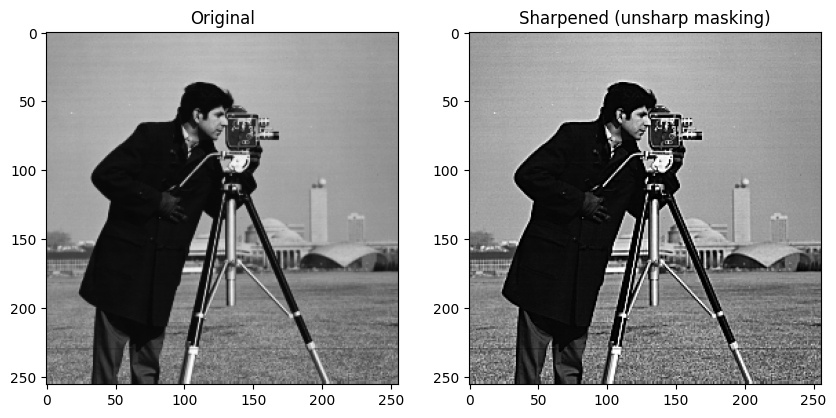

In [31]:
def sharpen(img, amount=1.0, kernel_size=5, sigma=1.0):
    """
    Unsharp masking: blur the image, subtract the blur from the original
    to get the "detail" (high-frequency) layer, then add that detail
    back on top of the original, scaled by `amount`.
    """
    blurred = gaussian_blur(img, kernel_size, sigma)
    detail = img.astype(float) - blurred
    sharpened = img.astype(float) + amount * detail
    return np.clip(sharpened, 0, 255)


sharp_img = sharpen(img, amount=1.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
axes[1].imshow(sharp_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Sharpened (unsharp masking)")
plt.show()

## 5. MSE and PSNR between the sharpened and original images
Compute the MSE and PSNR between your sharpened images and the original image.

In [32]:
amounts = [0.5, 1.0, 2.0, 3.0]

for a in amounts:
    result = sharpen(img, amount=a)
    print(f"amount={a:>4}:  MSE = {mse(img, result):8.3f}   PSNR = {psnr(img, result):6.2f} dB")


amount= 0.5:  MSE =   35.246   PSNR =  32.66 dB
amount= 1.0:  MSE =  113.829   PSNR =  27.57 dB
amount= 2.0:  MSE =  333.382   PSNR =  22.90 dB
amount= 3.0:  MSE =  585.705   PSNR =  20.45 dB


## 6. Impact of the sharpening filter on MSE and PSNR
Analyse the impact of the sharpening filter on the MSE and PSNR metrics.

**Your analysis:**


Sharpening always increases the MSE (and therefore decreases the PSNR) relative to the original image, because unsharp masking deliberately adds the high-frequency detail layer back on top of the image, which changes pixel values away from the original even though the result looks more visually "crisp".
As amount increases, more of the detail layer is added, so the MSE keeps growing and the PSNR keeps dropping, while edges/textures appear increasingly enhanced (and at very high amount, halo artefacts and noise amplification start to appear, since noise is also a high-frequency component that gets boosted).
This highlights that MSE/PSNR measure numerical closeness to the original, not perceptual quality: a sharpened image can look subjectively better to a human viewer while still scoring worse on MSE/PSNR.